In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Roteiros
quotes = pd.read_csv('../data/raw/friends_quotes.csv')

# Corrige tipos de dados
quotes['season'] = quotes['season'].astype(int)
quotes['episode_number'] = quotes['episode_number'].astype(int)

# Episódios da API (já limpos)
episodios = pd.read_csv('../data/processed/episodios_omdb.csv')

# Filtra só os 6 personagens principais
principais = ['Rachel', 'Monica', 'Phoebe', 'Ross', 'Chandler', 'Joey']
quotes_principais = quotes[quotes['author'].isin(principais)]

# Remove temporada 2 por dados incompletos
quotes_principais = quotes_principais[quotes_principais['season'] != 2]

print("Quotes:", quotes_principais.shape)
print("Episódios:", episodios.shape)

Quotes: (45130, 6)
Episódios: (235, 8)


In [2]:
contagem = quotes_principais['author'].value_counts().reset_index()
contagem.columns = ['personagem', 'falas']
print(contagem)

  personagem  falas
0     Rachel   8237
1       Ross   8020
2     Monica   7457
3   Chandler   7445
4       Joey   7326
5     Phoebe   6645


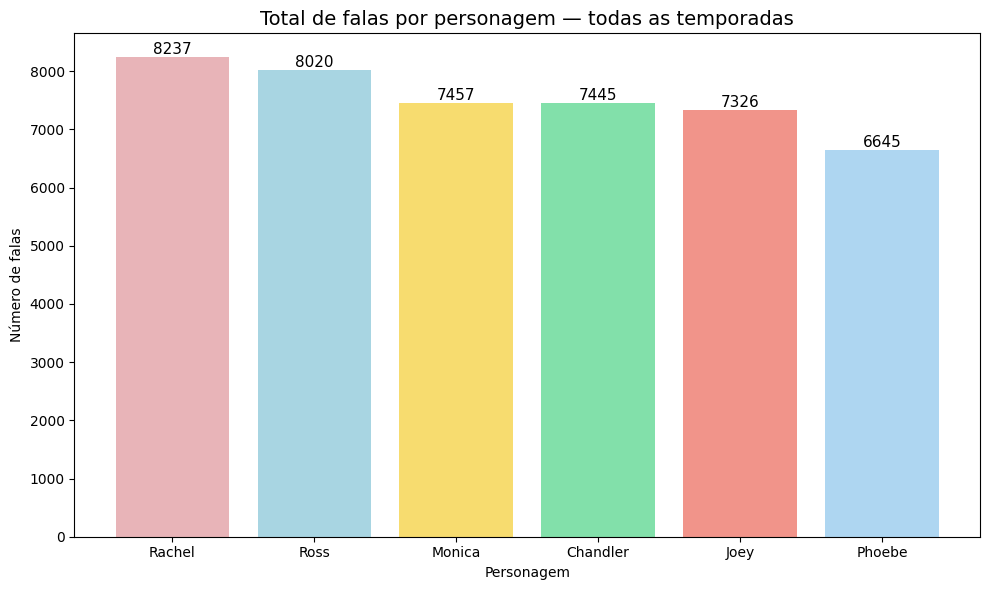

In [3]:
cores = ['#E8B4B8', '#A8D5E2', '#F7DC6F', '#82E0AA', '#F1948A', '#AED6F1']

plt.figure(figsize=(10, 6))
plt.bar(contagem['personagem'], contagem['falas'], color=cores)
plt.title('Total de falas por personagem — todas as temporadas', fontsize=14)
plt.xlabel('Personagem')
plt.ylabel('Número de falas')

for i, row in contagem.iterrows():
    plt.text(i, row['falas'] + 50, str(row['falas']), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/falas_por_personagem.png', dpi=150)
plt.show()

In [4]:
rating_temporada = episodios.groupby('temporada')['rating_imdb'].mean().reset_index()
rating_temporada.columns = ['temporada', 'rating_medio']
rating_temporada['rating_medio'] = rating_temporada['rating_medio'].round(2)
print(rating_temporada)

   temporada  rating_medio
0          1          8.13
1          2          8.26
2          3          8.27
3          4          8.32
4          5          8.48
5          6          8.31
6          7          8.26
7          8          8.24
8          9          8.11
9         10          8.51


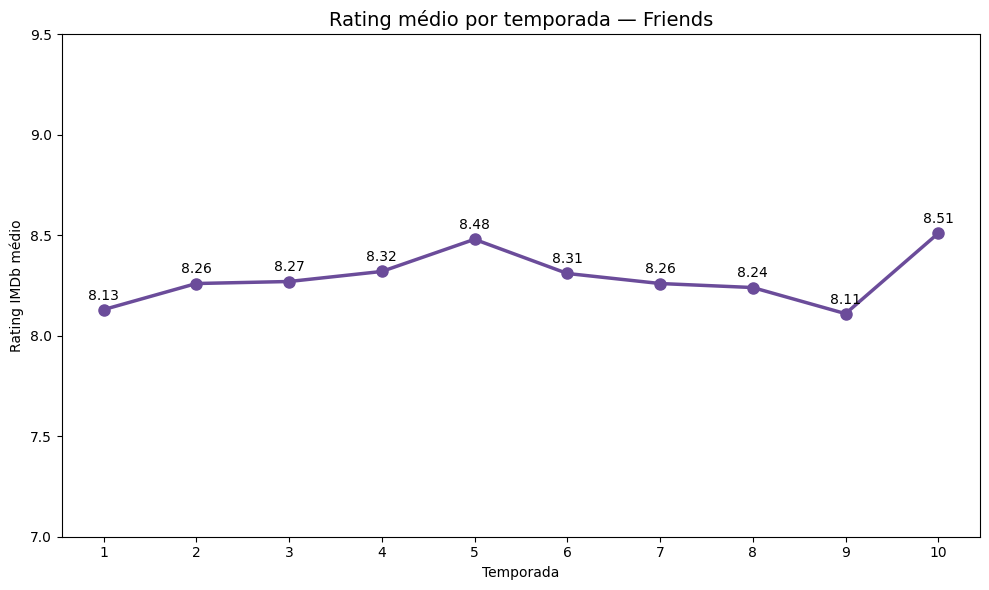

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(rating_temporada['temporada'], rating_temporada['rating_medio'],
         marker='o', color='#6B4C9A', linewidth=2.5, markersize=8)

plt.title('Rating médio por temporada — Friends', fontsize=14)
plt.xlabel('Temporada')
plt.ylabel('Rating IMDb médio')
plt.xticks(range(1, 11))
plt.ylim(7, 9.5)

for _, row in rating_temporada.iterrows():
    plt.text(row['temporada'], row['rating_medio'] + 0.05,
             str(row['rating_medio']), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/rating_por_temporada.png', dpi=150)
plt.show()
